## Esame di Adv Sim Tech: Machine Learing nell'analisi dei Raggi Cosmici
*Autore: Roberto Di Loreto, matr. n° 302122*

Lo scopo di questo progetto è quello di verificare la validità e potenzialità di metodi di Machine Learing (ML) nella fisica dei raggi cosmici; in particolare, si vuole studiare come i metodi ML possano migliorare la ricostruzione dell'energia di eventi registrati dai telescopi del *Pierre Auger Observatory* (Pierre Auger Open Data).

I laboratori Pierre Auger utilizzano un metodo ricostruttivo dell'energia noto come Constant Intensity Cut (CIC). Questo metodo si basa su un'assunzione molto potente e delicata allo stesso tempo: il flusso di raggi cosmici è isotropo (stessa intensità in ogni direzione).

Da ciò deriva che per ogni angolo zenitale deve esserci un certo numero di eventi sopra una soglia fissata. Questa assunzione ha permesso di ricostruire una curva di attenuazione, ovvero di descrivere come segnali ad angoli maggiori subissero una diminuzione di intensità causata dal dover attraversare uno strato di atmosfera più lungo.
Il vantaggio principale del CIC sta nel non dipendere troppo dal modello teorico che descrive i raggi cosmici, infatti risulta molto efficace per eventi di tipo misto (protoni, nuclei pesanti)

Come anticipato, l'assunsione di flusso isotropo è delicata poiché non generale, infatti a scale più alte si osservano delle anomalie. L'altro problema principale sta nelle fluttuazioni naturali degli sciami cosmici, che portano ad imprecisioni in queste curve di attenuazione.

Proprio per questo motivo può essere istruttivo applicare metodi di ML che *affiancano l'attuale CIC* al fine di correggere evento per evento la ricostruzione di energia. Questa è l'idea su cui si basa il seguente progetto.

## Dataset Pierre Auger Open Data

I laboratori hanno pubblicato vari set di dati raccolti dal 2004 fino al 2021, reperibili al link https://opendata.auger.org/data.php. Sono presenti un file di pseudo-raw data ed uno sommario, contenente solo il 10% dei dati raccolti e revisionati secondo criteri di selezione che li rendono adatti alla maggior parte delle analisi statistiche. 

La prima operazione consiste nell'estrazione dati da questi files in formato ".csv", al fine di visionare la dimensione (n. di righe/colonne) e le caratteristiche principali.

In [1]:
import numpy as np
import pandas as pd
import csv
from pathlib import Path

# Usa la cartella corrente del notebook, che in Jupyter di solito è la cartella del file .ipynb

base_dir = Path.cwd()
dir_path = base_dir / "summary"
csv_files = sorted(dir_path.glob("*.csv"))

if not csv_files:
    raise FileNotFoundError(f"Nessun CSV trovato in: {dir_path}")

database = []
all_headers = []

for myfile in csv_files:
    with open(myfile, 'r') as f:
        reader = csv.reader(f)
        header = next(reader)  # Legge l'intestazione del file CSV
        all_headers.append(header)
        dataset = [[str(cell) for cell in row] for row in reader]  # Mantieni i valori come stringhe
        database.append(dataset)
    print("Lettura file completata:", myfile.name,'\n')
    print("Righe:", len(database[-1])+1,'\n')
    print(all_headers[-1],'\n','\n')       # Stampa la prima riga dell'ultimo dataset caricato


Lettura file completata: dataSummaryInclined.csv 

Righe: 2356 

['id', 'sdid', 'gpstime', 'sd1500', 'multiEye', 'sd_gpsnanotime', 'sd_theta', 'sd_dtheta', 'sd_phi', 'sd_dphi', 'sd_energy', 'sd_denergy', 'sd_l', 'sd_b', 'sd_ra', 'sd_dec', 'sd_x', 'sd_dx', 'sd_y', 'sd_dy', 'sd_z', 'sd_easting', 'sd_northing', 'sd_altitude', 'sd_n19', 'sd_dn19', 'sd_n68', 'sd_dn68', 'sd_nbstat', 'sd_geondf', 'sd_geochi2', 'sd_exposure'] 
 

Lettura file completata: dataSummarySD1500.csv 

Righe: 24320 

['id', 'sdid', 'gpstime', 'sd1500', 'multiEye', 'sd_gpsnanotime', 'sd_theta', 'sd_dtheta', 'sd_phi', 'sd_dphi', 'sd_energy', 'sd_denergy', 'sd_l', 'sd_b', 'sd_ra', 'sd_dec', 'sd_x', 'sd_dx', 'sd_y', 'sd_dy', 'sd_z', 'sd_easting', 'sd_northing', 'sd_altitude', 'sd_R', 'sd_dR', 'sd_s1000', 'sd_ds1000', 'sd_s38', 'sd_gcorr', 'sd_wcorr', 'sd_beta', 'sd_gamma', 'sd_chi2', 'sd_ndf', 'sd_geochi2', 'sd_geondf', 'sd_nbstat', 'fd_id', 'fd_gpsnanotime', 'fd_hdSpectrumEye', 'fd_hdCalibEye', 'fd_hdXmaxEye', 'fd_theta'

## Scelta del dataset

La cartella degli Open Data è suddivisa in tre files in base al tipo di misura effettuata per acquisirli. I primi due sfruttano dei *Surface Detectors* (SD) posti in una griglia a triangoli e distanti l'uno dall'altro rispettivamente 1500 metri e 750 metri; il terzo dataset presenta misure cosiddette "inclinate", ovvero ad angoli zenitali molto grandi (60°-80°), e riguarda principalmente la stima dell'energia del primario di uno sciame (non usa CIC).

Per lo scopo del progetto, il dataset SD750 potrebbe essere il compromesso utile, dato che l'array più denso genera un numero di dati sufficiente per far lavorare al meglio i modelli ML. Il dataset SD1500 potrebbe essere usato come test o per supporto, con le opportune accortezze.

## Analisi delle variabili chiave

Dopo aver individuato l'array di lavoro, il prossimo passo è cercare di capire quali variabili contiene il dataset, in modo da capire quali di queste potrebbero influenzare una ricostruzione shower-by-shower. Il metodo CIC sfrutta essenzialmente la ricostruzione del segnale ideale per l'array di riferimento (*s1000* per SD1500 e *s450* per SD750) e l'angolo zenitale associato ad ogni sciame (anzi il coseno quadro, legato all'intensità del segnale). Il file sommario ricostruito in Open Data presenta numerose righe con variabili aggiuntive a cui non è associato un valore, questo perché gli eventi selezionati sono principalmente osservati a terra da SD ma esistono detector a fluorescenza (FD) che servono a tracciare lo sciame in atmosfera.
\
Si può controllare se questi eventi formano un campione sufficiente da analizzare con ML.

***N.B.** il file manca della colonna 72, ovvero del valore SD38 che è il riferimento ottimale per stimare la curva di attenuazione. Questo fatto viene considerato nella ricerca delle righe "piene".*

In [2]:
# Scelta del dataset da utilizzare, ovvero SD750

myheader = all_headers[2]
mydata = database[2]

print("Header scelto:", myheader,'\n')

# Check sui dati SD-FD. Elimino la riga s38
mydata = np.delete(mydata, myheader.index('sd_s38'), axis=1)
myheader.remove('sd_s38')

# Check dati con fd
fd_cols = [i for i, col in enumerate(myheader) if col.startswith('fd_')]
complete_rows = 0
for i in range(len(mydata)):
    for j in fd_cols:
        if mydata[i][j] != '':
            complete_rows += 1
            break  # Esci dal ciclo interno se trovi almeno un dato in una colonna FD

print("Numero di righe con dati FD:", complete_rows,'\n')

# Elimino le colonne FD dai dati se irrilevanti per ML.
if float(complete_rows) < 0.2 * float(len(mydata)):
    print("Percentuale irrilevante per ML:", f'{complete_rows/len(mydata)*100:.2f}%','\n' )
    print("Elimino colonne FD dai dati\n")
    mydata = np.delete(mydata, fd_cols, axis=1)
    myheader = [col for i, col in enumerate(myheader) if i not in fd_cols]

    print("Header dopo eliminazione colonne FD ed s38\n", myheader,'\n')
    print("Numero di colonne dopo eliminazione:", len(myheader),'\n')
    print("Riga esempio:\n", mydata[0])
else:
    print("Percentuale rilevante per ML:", f'{complete_rows/len(mydata)*100:.2f}%','\n' )
    print("Mantengo le colonne FD dai dati\n")

Header scelto: ['id', 'sdid', 'gpstime', 'sd750', 'multiEye', 'sd1500', 'sd_gpsnanotime', 'sd_theta', 'sd_phi', 'sd_energy', 'sd_l', 'sd_b', 'sd_ra', 'sd_dec', 'sd_x', 'sd_dx', 'sd_y', 'sd_dy', 'sd_z', 'sd_easting', 'sd_northing', 'sd_altitude', 'sd_s450', 'sd_ds450', 'sd_s35', 'sd_beta', 'sd_gamma', 'sd_chi2', 'sd_ndf', 'sd_geochi2', 'sd_nbstat', 'fd_id', 'fd_gpsnanotime', 'fd_hdSpectrumEye', 'fd_hdCalibEye', 'fd_hdXmaxEye', 'fd_theta', 'fd_dtheta', 'fd_phi', 'fd_dphi', 'fd_l', 'fd_b', 'fd_ra', 'fd_dec', 'fd_totalEnergy', 'fd_dtotalEnergy', 'fd_calEnergy', 'fd_dcalEnergy', 'fd_xmax', 'fd_dxmax', 'fd_heightXmax', 'fd_distXmax', 'fd_dEdXmax', 'fd_ddEdXmax', 'fd_x', 'fd_dx', 'fd_y', 'fd_dy', 'fd_z', 'fd_easting', 'fd_northing', 'fd_altitude', 'fd_cherenkovFraction', 'fd_minViewAngle', 'fd_uspL', 'fd_duspL', 'fd_uspR', 'fd_duspR', 'fd_hottestStationId', 'fd_distSdpStation', 'fd_distAxisStation', 'sd_s38', 'sd_gpstime', 'sd_exposure'] 

Numero di righe con dati FD: 197 

Percentuale irrile

**OSSERVAZIONI (1)**

Si può notare che il numero di eventi con righe complete è molto piccolo, per cui è consigliabile lavorare su tutti gli altri dati riducendo la matrice di partenza alle sole colonne "piene". Dato che le righe con valori mancanti sono tutte uguali, lavoro semplicemente sulla prima riga, selezionando le colonne da eliminare.

Sul sito del Pierre Auger Observatory sono indicate tutte le variabili misurate (dirrettamente o indirettamente) e contenute nei diversi file associati agli eventi. Nel sommario troviamo 33 di queste, che possiamo suddividere in variabili *info*, *flags*, *SD recostructed* (*sdrec*).

I 192 eventi trovati nella sezione precedente sono essenzialmente quelli con misure dei detector a fluorescenza (fdrec): sono noti come "golden-hybrid" events. Come suggerisce il nome, gli eventi di questo tipo sono di grande valore poiché hanno superato criteri di selezione di ben due classi di rivelatori. Possono essere gli eventi di base per una corretta calibrazione dei modelli ML.
\
Le variabili su cui i modelli ML potrebbero essere effettivamente usati sono proprio le *sdrec* Tra queste, notiamo la presenza degli errori associati alle misure, fondamentali nella ricostruzione in alcuni modelli.

Per comodità, separiamo il dataset rimanente in sotto-array di info, misure ed errori. Separiamo a parte l'esposizione (utile solo per flussi) ed il tempo gps.

In [3]:
# Separo gps ed exposure dal dataset principale

exposure = mydata[:, -1]
mydata = np.delete(mydata, -1, axis=1)
myheader = np.delete(myheader, -1, axis=0)
gps_time = mydata[:, -1]
# print(myheader, len(myheader), '\n')
mydata = np.delete(mydata, -1, axis=1)
myheader = np.delete(myheader, -1, axis=0)
# print(myheader, len(myheader), '\n')

# Check di eventuali buchi
for i in range(len(mydata)):
    for j in range(len(mydata[0])):
        if mydata[i][j] == '':
            print(f"Missing value at row {i},# column {myheader[j]}")

Missing value at row 47601,# column sd_s35
Missing value at row 47695,# column sd_s35


Avendo determinato righe con valori mancanti in `sd_s35`, dato che questi non sono importanti per i processi successivi (ho già `sd_s450`), escludiamo anche questi dal dataset principale. In questo modo, il dataset finale sarà composto dalle sole 30 colonne utili per la ricostruzione dell'energia shower-by-shower.

In [4]:
# Separo s35
idx = []
for i in range(len(myheader)):
    if myheader[i] == 'sd_s35':
        idx.append(i)
sd35 = mydata[:, idx]
mydata = np.delete(mydata, idx, axis=1)
myheader = np.delete(myheader, idx, axis=0)

#print(myheader, '\n')

# Continuo con divisione in info, variabili, errori

mydata_info = mydata.copy()
mydata_var = mydata.copy()
mydata_err = mydata.copy()

# Le info sono le prime 7 entrate

infolist = []
for i in range(7):
    infolist.append(myheader[i])

errorlist = ['sd_dx', 'sd_dy', 'sd_ds450', 'sd_chi2', 'sd_ndf', 'sd_geochi2', 'sd_nbstat']
varlist = []

for i in range(len(myheader)):
    if myheader[i] not in infolist and myheader[i] not in errorlist:
        varlist.append(myheader[i])

mydata_info = np.delete(mydata_info, slice(7,len(mydata_info[0])), axis=1 )
mydata_err = np.delete(mydata_err, [np.where(myheader == cell)[0][0] for cell in myheader if cell not in errorlist], axis=1)
mydata_var = np.delete(mydata_var, [np.where(myheader == cell)[0][0] for cell in myheader if cell not in varlist], axis=1)

print("Tabella riassuntiva:\n")
print(f"{'Info':<20}{'Variabile':<20}{'Errore':<20}",'\n')
for i in range(len(varlist)):
    if i < len(infolist):    
        print(f"{infolist[i]:<20}{varlist[i]:<20}{errorlist[i]:<20}")
    else:
        print(f"{'':<20}{varlist[i]:<20}{'':<20}")

#Last check
for elem in myheader:
    if elem not in infolist and elem not in errorlist and elem not in varlist:
        print("Errore!")


Tabella riassuntiva:

Info                Variabile           Errore               

id                  sd_theta            sd_dx               
sdid                sd_phi              sd_dy               
gpstime             sd_energy           sd_ds450            
sd750               sd_l                sd_chi2             
multiEye            sd_b                sd_ndf              
sd1500              sd_ra               sd_geochi2          
sd_gpsnanotime      sd_dec              sd_nbstat           
                    sd_x                                    
                    sd_y                                    
                    sd_z                                    
                    sd_easting                              
                    sd_northing                             
                    sd_altitude                             
                    sd_s450                                 
                    sd_beta                                 


__OSSERVAZIONI (3)__

I veri e propri errori sulle misure sono solo quelli di posizione del nucleo dello sciame (`sd_dx`,`sd_dy`) e sull'energia di riferimento `sd_ds450`, poiché gli altri valori sono dei *filtri di qualità*.
\
Guardiamo ad esempio `sd_chi2`: esso rappresenta il $\chi{}^2$ associato alla cosiddetta _Lateral Distribution Function_ (LDF), ovvero la funzione che predice il legame tra energia dello sciame ed angolo di entrata rispetto al riferimento s450. Questo dato ci dice quanto un singolo evento rispetti la relazione del modello scelto.
\
In combinazione con il numero di gradi di libertà (rapporto `sd_chi2`/`sd_ndf`) viene fornito un valore di riferimento per decidere se quel dato è coerente con LDF oppure no. Se si sceglie una soglia bassa, si ottengono pochi dati molto precisi; al contrario, per una soglia alta si hanno molti dati ma più vari. Un dato simile è `sd_geochi2`.

Un altro filtro importante è `sd_nbstat`, che indica il numero di stazioni della griglia che registrano un segnale sopra soglia. Più questo numero è alto, più il segnale è buono. Questo filtro però è delicato dato che a sua volta dipende dall'energia e dall'angolo: sciami verticali o altissime energie alzano il numero di stazioni, ma buona parte degli eventi non sono di questo tipo.
\
Nuovamente bisogna scegliere con moderazione come filtrare per non avere pochi dati precisi o troppi ma imprecisi.

## Applicazione dei metodi ML - Regressione Lineare

Dopo aver scelto le variabili di interesse, si può passare all'implementazione di metodi ML. Il primo modello applicabile è sicuramente la __regressione lineare__.
\
Sappiamo che il metodo CIC lavora sull'energia di uno sciame e la associa con la sola componente angolare. Possiamo dunque scegliere la variabile `sd_energy` come variabile dipendente dalle altre. La regressione permetterà di trovare i parametri che minimizzano lo scarto quadratico tra i dati e la relazione lineare.

Prima di applicare la regressione lineare, andiamo a filtrare i dati secondo criteri di selezione utili al fine di non avere del rumore eccessivo. L'idea è quella di scartare tutti quei dati il cui segnale di riferimento (`sd_s450`) è poco preciso ed il rapporto `sd_chi2`/`sd_ndf` è ragionevole.

In [5]:
# Check sulle energie

low_count = mid_count = high_count = 0
pos = []
high_pos = []
low_en_dat = []

for i in range(len(mydata_var)):
    num = mydata_err[i, [j for j in range(len(errorlist)) if errorlist[j] == 'sd_ds450'][0]]
    den = mydata_var[i, [j for j in range(len(varlist)) if varlist[j] == 'sd_s450'][0]]
    if num == '':
        print("Errore `sd_ds450` mancante, ID:", mydata_info[i, 0], '\n')
        pos.append(i)
    elif den == '':
        print("Segnale `sd_s450` mancante, ID:", mydata_info[i, 0], '\n')
        pos.append(i)
    continue
# Cut dei segnali mancanti

for i in sorted(pos, reverse=True):
    mydata_var = np.delete(mydata_var, i, axis=0)
    mydata_err = np.delete(mydata_err, i, axis=0)
    mydata_info = np.delete(mydata_info, i, axis=0)

# Analisi range energie
tot = 0

for i in range(len(mydata_var)):    
    tot += 1
    num = mydata_err[i, [j for j in range(len(errorlist)) if errorlist[j] == 'sd_ds450'][0]]
    den = mydata_var[i, [j for j in range(len(varlist)) if varlist[j] == 'sd_s450'][0]]
    sd_ratio = float(num) / float(den)
    if sd_ratio <= 2.5:
        low_count += 1
    elif sd_ratio <= 4:
        mid_count += 1
    else:
        high_count += 1
        high_pos.append(i)
        # print(high_pos[-1])
        low_en_dat.append(mydata_var[i])


print("Alte energie:", low_count,
    "   Energie mid-range:", mid_count,
    "   Energie piccole:", high_count,
    "   No s450:" if tot == 54481 and len(pos) != 0 else  '', len(pos) if tot == 54481 and len(pos) != 0 else '',
    "   Totale:", tot, 
    '\n'
    )

for i in sorted(high_pos, reverse=True):
    mydata_var = np.delete(mydata_var, i, axis=0)
    mydata_err = np.delete(mydata_err, i, axis=0)
    mydata_info = np.delete(mydata_info, i, axis=0)

# print(np.shape(mydata_var), '\n')

# Check su chi^2/ndf

low_count = mid_count = high_count = 0
filter_ratio = []
for i in range(len(mydata_err)):
    filter_ratio.append(float(mydata_err[i, 2])/float(mydata_err[i, -1]))
    if filter_ratio[i] <= 2.5:
        low_count += 1
    elif filter_ratio[i] >= 2.5 and filter_ratio[i] <= 4:
        mid_count += 1
    else:
        high_count += 1

tot = low_count + mid_count + high_count + len(pos) 
if tot == 54481 - len(high_pos):
    print("Dopo il taglio (`sd_ratio`<4)", tot + len(high_pos), "-->", tot - len(pos), '\n')

print("Dati precisi:", low_count,
    "   Dati mid-range:", mid_count,
    "   Rapporto grande:", high_count,
    "   Totale:", tot - len(pos),
    )



Alte energie: 54439    Energie mid-range: 5    Energie piccole: 37      Totale: 54481 

Dopo il taglio (`sd_ratio`<4) 54481 --> 54444 

Dati precisi: 54426    Dati mid-range: 11    Rapporto grande: 7    Totale: 54444


Alcuni dati possono essere eliminati a causa dell'assenza di segnale `sd_s450`. Questo può succedere per vari motivi, ad esempio una saturazione elettronica data da un segnale ad energia troppo elevata oppure un semplice problema tecnico dei rivelatori.

Dato che la regressione lineare è un processo in cui i coefficienti hanno un significato fisico, non avrebbe senso considerare le tutte 16 variabili in `varlist` perché questo aumenterebbe la varianza del modello in maniera incoerente, ovvero dando un risultato ottimo per i dati scelti ma completamente errato per un set diverso. Per poter usare un numero minore di variabili si ricorre a processi di *regolarizzazione* (Ridge e LASSO, o combinazione dei due in Elastic Net).

Dal punto di vista fisico, le variabili più importanti sono quelle che descrivono l'energia dello sciame e la sua direzione. Per questo motivo, si scelgono come variabili indipendenti `sd_s450`, `sd_theta`, `sd_phi`, `sd_gamma`, `sd_l` (alcune di queste sono  trigonometriche). In questo modo, il modello lineare sarà in grado di stimare l'energia di uno sciame a partire dalle misure dei detector a terra e dalla sua direzione di entrata.

In [6]:
# Aggiusto le variabili per la regressione lineare, in particolare gli angoli e l'energia

energy = np.log10(mydata_var[:, 2].astype(float))
#print("Mean energy", sum(energy) / len(energy)) e vedi che è -0.806

#print("Energie logaritmiche (esempio):", mydata_var[0, 2], "-->", f"{energy[0]:.2e}", '\n')
mydata_var = mydata_var.astype(float)
# occhio agli angoli --> cos(theta), sin(phi), cos(phi), ra, dec

cos_theta = np.zeros((len(mydata_var), 1))
sin_phi = np.zeros((len(mydata_var), 1))
cos_phi = np.zeros((len(mydata_var), 1))
sin_ra = np.zeros((len(mydata_var), 1))
cos_ra = np.zeros((len(mydata_var), 1))
sin_dec = np.zeros((len(mydata_var), 1))
cos_dec = np.zeros((len(mydata_var), 1))

#print(varlist, '\n')
#print(varlist.index('sd_theta'), varlist.index('sd_phi'), varlist.index('sd_ra'), varlist.index('sd_dec'), '\n')

for i in range(len(mydata_var)):
    cos_theta[i][0] = (np.cos(np.radians(mydata_var[i, varlist.index('sd_theta')])))
#
    sin_phi[i][0] = np.sin(np.radians(mydata_var[i, varlist.index('sd_phi')]))    
    cos_phi[i][0] = np.cos(np.radians(mydata_var[i, varlist.index('sd_phi')]))
#
    sin_ra[i][0] = np.sin(np.radians(mydata_var[i, varlist.index('sd_ra')]))
    cos_ra[i][0] = np.cos(np.radians(mydata_var[i, varlist.index('sd_ra')]))
#
    sin_dec[i][0] = np.sin(np.radians(mydata_var[i, varlist.index('sd_dec')]))
    cos_dec[i][0] = np.cos(np.radians(mydata_var[i, varlist.index('sd_dec')]))
#
sep_var = mydata_var.copy()
sep_var = np.delete(sep_var, [varlist.index('sd_theta'), 
                              varlist.index('sd_phi'), 
                              varlist.index('sd_energy'),
                              varlist.index('sd_ra'),
                              varlist.index('sd_dec')], axis=1)
set_of_vars = np.column_stack((sep_var, cos_theta, sin_phi, cos_phi, sin_ra, cos_ra, sin_dec, cos_dec))

this_varlist = varlist.copy()
this_varlist = np.delete(this_varlist, [varlist.index('sd_theta'),
                                        varlist.index('sd_phi'),
                                        varlist.index('sd_energy'),
                                        varlist.index('sd_ra'),
                                        varlist.index('sd_dec')])
this_varlist = np.append(this_varlist, ['cos(theta)', 'sin(phi)', 'cos(phi)', 'sin(ra)', 'cos(ra)', 'sin(dec)', 'cos(dec)'])

#for i in range(len(set_of_vars[0])):
     #print(f"Variabile {i}: {this_varlist[i]}")
     #print("Verifica:", set_of_vars[0][i] ,"=?=",mydata_var[0][i])

# Definisco la parte di dataset per il training (80%)

train_size = int(len(set_of_vars) * 0.8)

#############################################################################################################

# Modello intuitivo

#############################################################################################################

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.exceptions import ConvergenceWarning
import warnings

# Imposta una policy globale per tutti i fit successivi nel notebook.
warnings.filterwarnings(
    "once",
    category=ConvergenceWarning,
    module="sklearn.linear_model._coordinate_descent"
 )

keep_list = ['cos(theta)', 'sd_s450', 'sd_gamma', 'sd_l', 'sd_beta']
keep_idx = [i for i, var in enumerate(this_varlist) if var in keep_list]
model = LinearRegression(fit_intercept=True)
scaler = StandardScaler()
keep_vars_trainscaled = scaler.fit_transform(set_of_vars[:train_size, keep_idx])  # Standardizza solo le variabili selezionate per il training
model.fit(keep_vars_trainscaled, energy[:train_size])
keep_vars_testscaled = scaler.transform(set_of_vars[train_size:, keep_idx])  # Standardizza tutte le variabili per il testing

energy_pred = model.predict(keep_vars_testscaled)
mse = mean_squared_error(energy[train_size:], energy_pred)
residuals = energy[train_size:] - energy_pred
r2 = r2_score(energy[train_size:], energy_pred)


print("=" * 80, '\n')
print("             Regressione Lineare con selezione manuale", '\n')
print("=" * 80, '\n')

for i in range(len(keep_list)):
    print(f"{'Variabile selezionata':<25}{keep_list[i]:<15}{'Coefficiente:':<20}{model.coef_[i]:.4f}")
print()
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2): {r2:.4f}")
print(f"Bias:", f"{np.mean(energy[train_size:] - energy_pred):.4f}\n")
#print(f"Residuals (mean):", f"{np.mean(residuals):.4f}\n")

#############################################################################################################

# Esplorazione tramite ELASTIC NET

#############################################################################################################

print("=" * 80, '\n')
print("             Modello esplorativo (1) - ELASTIC NET", '\n')
print("=" * 80, '\n')

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

enet = ElasticNetCV(
    l1_ratio = [.1, .3, .5, .7, .9, .95, .97, .99, 1.0], # Se l1_ratio=1 ho LASSO
    alphas = np.logspace(-4, 0, 50),
    cv=5,
    max_iter=200000,
    random_state=42,
    fit_intercept=True
)

set_of_vars_trainscaled = scaler.fit_transform(set_of_vars[:train_size, :])  # Standardizza solo le variabili selezionate per il training
enet.fit(set_of_vars_trainscaled[:train_size, :], energy[:train_size])
selected_enet = np.where(enet.coef_ != 0)[0]
set_of_vars_testscaled = scaler.transform(set_of_vars[train_size:, :])  # Standardizza tutte le variabili per il testing
enet_energy_pred = enet.predict(set_of_vars_testscaled)
enet_mse = mean_squared_error(energy[train_size:], enet_energy_pred)
enet_residuals = energy[train_size:] - enet_energy_pred
enet_r2 = r2_score(energy[train_size:], enet_energy_pred)

print()
print(f"Elastic Net seleziona {len(selected_enet)} variabili:")
for i in selected_enet:
    print(f"{'Variabile selezionata':<25}{this_varlist[i]:<15}{'Coefficiente:':<20}{enet.coef_[i]:.4f}")

print(f"Mean Square Error (MSE): {enet_mse:.4f}")
print(f"R^2: {enet_r2:.4f}")
print(f"Bias:", f"{np.mean(energy[train_size:] - enet_energy_pred):.4f}\n")
#print(f"Residuals (mean):", f"{np.mean(enet_residuals):.4f}\n")


             Regressione Lineare con selezione manuale 


Variabile selezionata    cos(theta)     Coefficiente:       0.0004
Variabile selezionata    sd_s450        Coefficiente:       0.0537
Variabile selezionata    sd_gamma       Coefficiente:       -0.0215
Variabile selezionata    sd_l           Coefficiente:       0.1143
Variabile selezionata    sd_beta        Coefficiente:       -0.0545

Mean Squared Error (MSE): 0.0173
R-squared (R2): 0.5313
Bias: -0.0013


             Modello esplorativo (1) - ELASTIC NET 



Elastic Net seleziona 3 variabili:
Variabile selezionata    sd_s450        Coefficiente:       0.0462
Variabile selezionata    sd_gamma       Coefficiente:       0.1026
Variabile selezionata    cos(theta)     Coefficiente:       -0.0203
Mean Square Error (MSE): 0.0176
R^2: 0.5238
Bias: -0.0010



## Regressione lineare - Primi risultati

Una regressione lineare con le variabili selezionate manualmente produce un risultato interessante. Il modello è in grado di stimare l'energia di uno sciame con un errore quadratico medio (MSE) e un coefficiente di determinazione (R2) che indicano una scarsa capacità predittiva. Questo suggerisce che il modello lineare non è sufficiente per catturare la complessità dei dati e che potrebbero essere necessarie ulteriori variabili o modelli più complessi.


La selezione manuale delle variabili è supportata da un'analisi esplorativa tramite Elastic Net, un modello che combina le proprietà di Ridge e LASSO, permettendo di selezionare automaticamente le variabili più rilevanti. L'Elastic Net ha selezionato un numero limitato di variabili (`sd_s450`, `sd_gamma`, `cos(theta)`), confermando l'importanza delle variabili scelte manualmente e suggerendo che altre variabili potrebbero non contribuire significativamente alla predizione dell'energia dello sciame.


Un ultieriore controllo può essere fatto sfruttando delle variabili "ingegnerizzate" a partire da quelle già presenti, come ad esempio il quadrato del coseno dell'angolo zenitale, che potrebbe catturare meglio la relazione tra l'energia dello sciame e la sua direzione di entrata.

In [7]:
# Ingegnerizzazione

ing_vars = set_of_vars[:, keep_idx].copy()
ing_list = []
#print(set_of_vars[0])
#print(ing_vars[0], '\n')

for i in keep_idx:
    for j in keep_idx:
        if j >= i:
            x = set_of_vars[:, i] * set_of_vars[:, j]
            #print(set_of_vars[0][i], '*', set_of_vars[0][j],'=', x[0], "\n")
            ing_vars = np.column_stack((ing_vars, x))
            if i != j:
                ing_list.append(f"{this_varlist[i]}*{this_varlist[j]}")
            else:
                ing_list.append(f"{this_varlist[i]}^2")

#print(ing_vars[0])
ing_vars = np.delete(ing_vars, [0,1,2,3,4], axis=1)

print("Costruzione di variabili ingegnerizzate completata. Ecco la lista con un esempio di valori:\n")
for i in range(len(ing_vars[0])):
    print(f"{'Variabile:':<20}{ing_list[i]:<30}{'Val. esempio:':<20}{ing_vars[0][i]:.4f}")

print('\n', '\n')
print("=" * 80, '\n')
print("             Modello intuitivo (2) - VARIABILI INGEGNERIZZATE", '\n')
print("=" * 80, '\n')

# Regressione con variabili ingegnerizzate
ing_vars_trainscaled = scaler.fit_transform(ing_vars[:train_size, :])  # Standardizza solo le variabili ingegnerizzate per il training

ing_enet = ElasticNetCV(
    l1_ratio = [.1, .3, .5, .7, .9, .95, .97, .99, 1.0], # Se l1_ratio=1 ho LASSO
    alphas = np.logspace(-4, 0, 50),
    cv=5,
    max_iter=200000,
    random_state=42,
    fit_intercept=True
)

ing_enet.fit(ing_vars_trainscaled[:train_size, :], energy[:train_size])
selected_ie = np.where(ing_enet.coef_ != 0)[0]
ing_vars_testscaled = scaler.transform(ing_vars[train_size:, :])  # Standardizza tutte le variabili per il testing
ie_energy_pred = ing_enet.predict(ing_vars_testscaled)
ie_mse = mean_squared_error(energy[train_size:], ie_energy_pred)
ie_residuals = energy[train_size:] - ie_energy_pred
ie_r2 = r2_score(energy[train_size:], ie_energy_pred)

print()
print(f"Elastic Net seleziona {len(selected_ie)} variabili:")
for i in selected_ie:
    print(f"{'Variabile selezionata':<25}{ing_list[i]:<25}{'Coefficiente:':<20}{ing_enet.coef_[i]:.4f}")

print(f"Mean Square Error (MSE): {ie_mse:.4f}")
print(f"R^2: {ie_r2:.4f}\n")
print(f"Bias:", f"{np.mean(energy[train_size:] - ie_energy_pred):.4f}\n")
#print(f"Residuals (mean):", f"{np.mean(ie_residuals):.4f}\n")

# Se selected_ie prende tutte le variabili, devo tagliare alcune non coerenti, 
# quindi restringo a quelle quadratiche e i prodotti selezionati dal primo Elastic Net

if len(selected_ie) >= len(ing_list): 
    print("\nTaglio variabili non coerenti, seleziono solo quelle quadratiche e i prodotti selezionati dal primo Elastic Net\n")
    #
    print("=" * 80, '\n')
    print("             Modello intuitivo (2) - VARIABILI INGEGNERIZZATE", '\n')
    print("=" * 80, '\n')
    ing_list_r = []
    for i in selected_ie:
        if ing_list[i].endswith('^2') or ing_list[i].__contains__('*sd_s450') or ing_list[i].__contains__('*sd_gamma') or ing_list[i].__contains__('*cos(theta)'):
            ing_list_r.append(ing_list[i])
    ing_vars_r = ing_vars[:, [i for i, var in enumerate(ing_list) if var in ing_list_r]]
    print(f"{'Ho ristretto a':<20}{len(ing_list_r)} variabili ingegnerizzate selezionate\n")
    print(f"{'Variabili ingegnerizzate selezionate:':<40}")
    for i in range(len(ing_list_r)):
        print(f"{ing_list_r[i]}")
    #

    ing_r_trainscaled = scaler.fit_transform(ing_vars_r[:train_size, :])  # Standardizza solo le variabili ingegnerizzate ristrette per il training
    #
    ing_enet_r = ElasticNetCV(
        l1_ratio = [.1, .3, .5, .7, .9, .95, .97, .99, 1.0], # Se l1_ratio=1 ho LASSO
        alphas = np.logspace(-4, 0, 50),
        cv=5,
        max_iter=200000,
        random_state=42,
        fit_intercept=True
    )
    #
    ing_enet_r.fit(ing_r_trainscaled[:train_size, :], energy[:train_size])
    selected_enet_r = np.where(ing_enet_r.coef_ != 0)[0]
    ing_r_testscaled = scaler.transform(ing_vars_r[train_size:, :])  # Standardizza tutte le variabili per il testing
    enet_energy_pred = ing_enet_r.predict(ing_r_testscaled)
    mse_r = mean_squared_error(energy[train_size:], enet_energy_pred)
    residuals_r = energy[train_size:] - enet_energy_pred
    r2_r = r2_score(energy[train_size:], enet_energy_pred)
    #
    print(f"Elastic Net seleziona {len(selected_enet_r)} variabili:")
    for i in selected_enet_r:
        print(f"{'Variabile selezionata':<25}{ing_list_r[i]:<30}{'Coefficiente:':<25}{ing_enet_r.coef_[i]:.4f}")
    #
    print(f"Mean Square Error (MSE): {mse_r:.4f}")
    print(f"R^2: {r2_r:.4f}")
    print(f"Bias:", f"{np.mean(energy[train_size:] - enet_energy_pred):.4f}\n")
#   print(f"Residuals (mean):", f"{np.mean(residuals_r):.4f}\n")
 

Costruzione di variabili ingegnerizzate completata. Ecco la lista con un esempio di valori:

Variabile:          sd_l^2                        Val. esempio:       133.6336
Variabile:          sd_l*sd_s450                  Val. esempio:       -204.8432
Variabile:          sd_l*sd_beta                  Val. esempio:       34.9112
Variabile:          sd_l*sd_gamma                 Val. esempio:       3.4680
Variabile:          sd_l*cos(theta)               Val. esempio:       -10.1582
Variabile:          sd_s450^2                     Val. esempio:       313.9984
Variabile:          sd_s450*sd_beta               Val. esempio:       -53.5144
Variabile:          sd_s450*sd_gamma              Val. esempio:       -5.3160
Variabile:          sd_s450*cos(theta)            Val. esempio:       15.5712
Variabile:          sd_beta^2                     Val. esempio:       9.1204
Variabile:          sd_beta*sd_gamma              Val. esempio:       0.9060
Variabile:          sd_beta*cos(theta)        

In [8]:
# Combino modello lineare con ingnegnerizzato: uso this_varlist[selected_enet] e ing_list

comb_list = np.concatenate((np.array(this_varlist)[selected_enet], np.array(ing_list)[selected_ie]))
for i in range(len(comb_list)):
    print(f"{'Variabile selezionata:':<25}{comb_list[i]}")
comb_vars = np.column_stack((set_of_vars[:, selected_enet], ing_vars[:, selected_ie]))
#print(comb_vars[0], '\n')
#print(set_of_vars[0][selected_enet], '\n')
#print(ing_vars[0][selected_ie], '\n')
print()

comb_vars_trainscaled = scaler.fit_transform(comb_vars[:train_size, :])  # Standardizza solo le variabili combinate per il training

comb_enet = ElasticNetCV(
    l1_ratio = [.1, .3, .5, .7, .9, .95, .97, .99, 1.0], # Se l1_ratio=1 ho LASSO
    alphas = np.logspace(-4, 0, 50),
    cv=5,
    max_iter=200000,
    random_state=42,
    fit_intercept=True
)

comb_enet.fit(comb_vars_trainscaled[:train_size, :], energy[:train_size])
selected_comb = np.where(comb_enet.coef_ != 0)[0]
comb_vars_testscaled = scaler.transform(comb_vars[train_size:, :])  # Standardizza tutte le variabili per il testing
comb_energy_pred = comb_enet.predict(comb_vars_testscaled)
comb_mse = mean_squared_error(energy[train_size:], comb_energy_pred)
comb_residuals = energy[train_size:] - comb_energy_pred
comb_r2 = r2_score(energy[train_size:], comb_energy_pred)

print("=" * 80, '\n')
print("             Modello esplorativo (3) - COMBINAZIONE", '\n')
print("=" * 80, '\n')

print(f"Elastic Net seleziona {len(selected_comb)} variabili:")
for i in selected_comb:
    print(f"{'Variabile selezionata':<25}{comb_list[i]:<30}{'Coefficiente:':<25}{comb_enet.coef_[i]:.4f}")

print(f"\nMean Square Error (MSE): {comb_mse:.4f}")
print(f"R^2: {comb_r2:.4f}")
print(f"Bias:", f"{np.mean(energy[train_size:] - comb_energy_pred):.4f}\n")
#print(f"Residuals (mean):", f"{np.mean(comb_residuals):.4f}\n")

Variabile selezionata:   sd_s450
Variabile selezionata:   sd_gamma
Variabile selezionata:   cos(theta)
Variabile selezionata:   sd_s450^2
Variabile selezionata:   sd_s450*sd_gamma
Variabile selezionata:   sd_beta*sd_gamma
Variabile selezionata:   sd_gamma^2


             Modello esplorativo (3) - COMBINAZIONE 


Elastic Net seleziona 7 variabili:
Variabile selezionata    sd_s450                       Coefficiente:            -1.7747
Variabile selezionata    sd_gamma                      Coefficiente:            0.7265
Variabile selezionata    cos(theta)                    Coefficiente:            -0.0505
Variabile selezionata    sd_s450^2                     Coefficiente:            0.2661
Variabile selezionata    sd_s450*sd_gamma              Coefficiente:            -1.6110
Variabile selezionata    sd_beta*sd_gamma              Coefficiente:            0.0024
Variabile selezionata    sd_gamma^2                    Coefficiente:            0.6256

Mean Square Error (MSE): 0.0026
R^2: 

__OSSERVAZIONI (4)__

Si può notare come il modello a variabili _ingegnerizzate_ migliori le performance rispetto al modello lineare semplice, suggerendo che la relazione tra le variabili non è puramente lineare e che trasformazioni delle variabili possono aiutare a catturare meglio la complessità dei dati.

Un'ulteriore miglioria è stata ottenuta combinando le variabili selezionate con l'Elastic Net e quelle ingegnerizzate, ottenendo un modello più robusto e con migliori capacità predittive. Questo approccio permette di sfruttare sia la conoscenza fisica delle variabili che le capacità di selezione automatica del modello.

## Metodi non lineari - Random Forest Method

In questa sezione si passerà ad analizzare lo stesso set di dati ma in maniera non lineare. L'idea è di utilizzare il modello ML noto come *Random Forest*.

Questo modello si basa su un insieme di alberi decisionali, ognuno dei quali viene addestrato su un sottoinsieme casuale dei dati. La previsione finale viene ottenuta combinando le previsioni di tutti gli alberi, riducendo così il rischio di overfitting e migliorando la capacità predittiva del modello. 


             Random Forest - Confronto Set di Variabili



    Selezione manuale (5 var)

   Training set: 43555 samples
   Test set: 10889 samples
   Variabili: 5


   Performance:
     R² (test): 0.9952
     MSE: 0.000178
     Bias: 0.000208

     Importanza variabili:
    sd_s450               0.9361
    sd_beta               0.0638
    sd_gamma              0.0001
    sd_l                  0.0000
    cos(theta)            0.0000


    Elastic Net (3 var)

   Training set: 43555 samples
   Test set: 10889 samples
   Variabili: 3


   Performance:
     R² (test): 0.9952
     MSE: 0.000178
     Bias: 0.000208

     Importanza variabili:
    sd_s450               0.9361
    cos(theta)            0.0639
    sd_gamma              0.0000


    Variabili ingegnerizzate Elastic Net (4 var)

   Training set: 43555 samples
   Test set: 10889 samples
   Variabili: 4


   Performance:
     R² (test): 0.9868
     MSE: 0.000490
     Bias: 0.000194

     Importanza variabili:
    sd_s450^2       

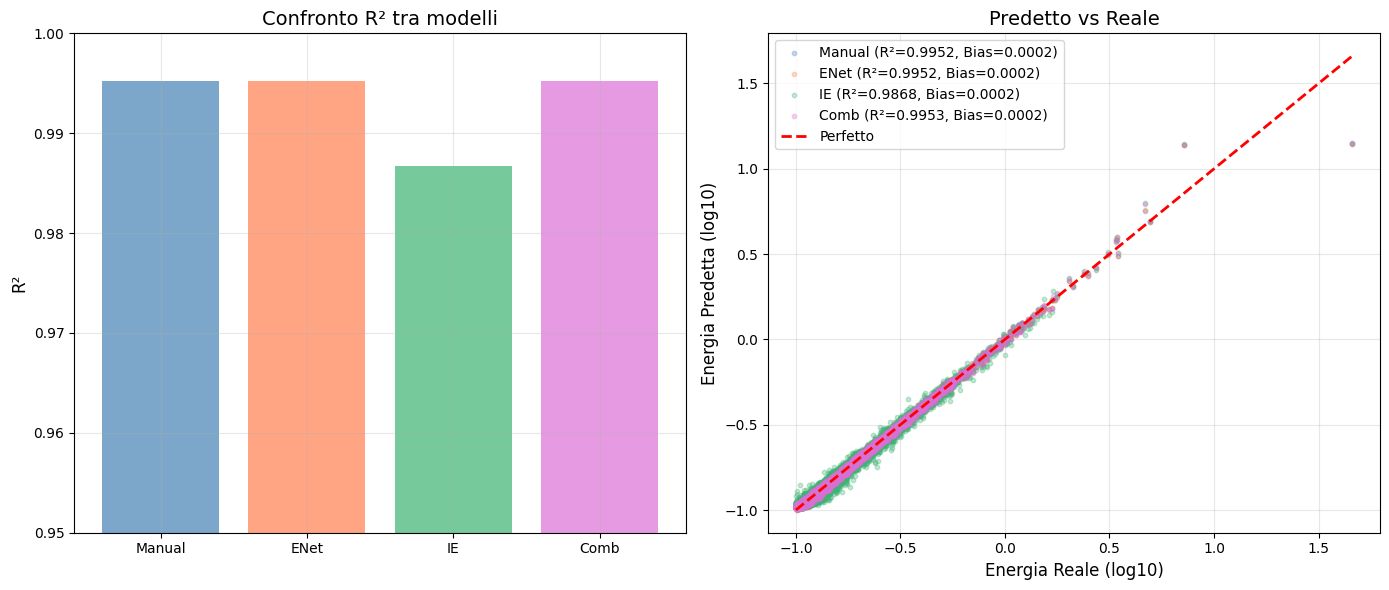


RIEPILOGO CONFRONTO
Modello                   R²         MSE          Variabili 
------------------------------------------------------------
Manual                    0.9952    0.000178          5
ENet                      0.9952    0.000178          3
IE                        0.9868    0.000490          4
Comb                      0.9953    0.000176          7

ANALISI COMPARATIVA

  Miglior modello: Combinazione (7 var)
   Residuals = 0.0132
   R² = 0.9953


In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

print("="*80, '\n')
print("             Random Forest - Confronto Set di Variabili\n")
print("="*80, '\n')

# --- Configurazione dei diversi set di variabili ---
configs = {
    'Selezione manuale (5 var)': {
        'colonne': keep_idx,  # Le 5 variabili selezionate manualmente
        'nomi': keep_list,
        'colore': 'steelblue',
        'sigla': 'Manual'
    },
    'Elastic Net (3 var)': {
        'colonne': selected_enet,  # Le variabili selezionate dal primo Elastic Net
        'nomi': [this_varlist[i] for i in selected_enet],
        'colore': 'coral',
        'sigla': 'ENet'
    },
    'Variabili ingegnerizzate Elastic Net (4 var)': {
        'colonne': selected_ie,  # Le variabili ingegnerizzate selezionate dal secondo Elastic Net
        'nomi': [ing_list[i] for i in selected_ie],
        'colore': 'mediumseagreen',
        'sigla': 'IE'
    },
    'Combinazione (7 var)': {
        'colonne': selected_comb,  # Le variabili combinate selezionate dal terzo Elastic Net
        'nomi': [comb_list[i] for i in selected_comb],
        'colore': 'orchid',
        'sigla': 'Comb'
    }
}

# Miglioria computazionale, ma tempi di calcolo lunghi, quindi uso parametri fissi per il Random Forest
param_grid_rf = {
    'n_estimators': [500, 1000],
    'max_depth': [10, 15, None],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

# --- Dizionario per salvare i risultati ---
results_rf = {}
models_rf = {}
predictions_rf = {}

# --- Ciclo su ogni configurazione ---
for config_name, config in configs.items():
    # 1. Seleziona le colonne per questo set
    colonne = config['colonne']
    nomi_var = config['nomi']
    conf_sigla = config['sigla']
    
    # 2. Prepara i dati
    if config_name == 'Variabili ingegnerizzate Elastic Net (4 var)':
        X_train = ing_vars[:train_size, colonne]
        X_test = ing_vars[train_size:, colonne]
    elif config_name == 'Combinazione (7 var)':
        X_train = comb_vars[:train_size, colonne]
        X_test = comb_vars[train_size:, colonne]
    else:
        X_train = set_of_vars[:train_size, colonne]
        X_test = set_of_vars[train_size:, colonne]
    y_train = energy[:train_size]
    y_test = energy[train_size:]
    
    print(f"\n{'='*50}")
    print(f"    {config_name}")
    print(f"{'='*50}\n")
    print(f"   Training set: {X_train.shape[0]} samples")
    print(f"   Test set: {X_test.shape[0]} samples")
    print(f"   Variabili: {X_train.shape[1]}\n")

    # 3. Addestra Random Forest (base)
    basic = True
    if basic == False:
        rf = RandomForestRegressor(random_state=42, n_jobs=-1)
        grid_search = GridSearchCV(
            estimator=rf,
            param_grid=param_grid_rf,
            cv=5,  # 5-fold cross-validation
            scoring='r2',
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)
        
        best_rf = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_cv_score = grid_search.best_score_
        
        importance = best_rf.feature_importances_

        y_pred = best_rf.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        residuals = y_test - y_pred
        bias = np.mean(y_test - y_pred)

        print(f"\n     Migliori parametri:")
        for param, value in best_params.items():
            print(f"      {param}: {value}")
        print(f"\n   Performance:")
        print(f"     R² (CV): {best_cv_score:.4f}")
        print(f"     R² (test): {r2:.4f}")
        print(f"     MSE: {mse:.6f}")
        print(f"     Bias: {bias:.6f}")

        
    elif basic == True:
        rf = RandomForestRegressor(
            n_estimators=500,
            max_depth=8,
            min_samples_split=5,
            min_samples_leaf=4,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        
        grid_search = rf  # Per uniformità di codice, anche se non c'è ricerca di griglia
        importance = rf.feature_importances_

        y_pred = rf.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        residuals = y_test - y_pred
        bias = np.mean(y_test - y_pred)

        print(f"\n   Performance:")
        print(f"     R² (test): {r2:.4f}")
        print(f"     MSE: {mse:.6f}")
        print(f"     Bias: {bias:.6f}")
    
    # 5. Importanza delle variabili
    print(f"\n     Importanza variabili:")
    # Ordina per importanza decrescente
    sorted_idx = np.argsort(importance)[::-1]
    for i in sorted_idx:
        if i < len(nomi_var):
            print(f"    {nomi_var[i]:<20}  {importance[i]:.4f}")
    print()
    
    # 6. Salva tutto
    results_rf[config_name] = {
        'r2': r2,
        'mse': mse,
        'bias': bias,
        'residuals': residuals,
        'n_var': X_train.shape[1]
    }
    if basic == False:
        models_rf[config_name] = best_rf
    elif basic == True:
        models_rf[config_name] = rf
    predictions_rf[config_name] = y_pred

# --- Grafico di confronto ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: R² e MSE a confronto
for i, (name, res) in enumerate(results_rf.items()):
    axes[0].bar(i, res['r2'], label=f"{configs[name]['sigla']}\n(R²={res['r2']:.4f})", 
                color=configs[name]['colore'], alpha=0.7)
axes[0].set_ylabel('R²', fontsize=12)
axes[0].set_title('Confronto R² tra modelli', fontsize=14)
axes[0].set_xticks(range(len(results_rf)))
axes[0].set_xticklabels([configs[name]['sigla'] for name in results_rf.keys()])
axes[0].grid(alpha=0.3)
for q in sorted(range(0, 20), reverse=True):
    if any(res['r2'] > q / 20 for res in results_rf.values()):
        axes[0].set_ylim(q / 20, 1)
        break
    else:
        axes[0].set_ylim(0, 1)

# Grafico 2: Predetto vs Reale per entrambi i modelli
for name, y_pred in predictions_rf.items():
    axes[1].scatter(energy[train_size:], y_pred, 
                    alpha=0.3, s=10, 
                    label=f"{configs[name]['sigla']} (R²={results_rf[name]['r2']:.4f}, Bias={results_rf[name]['bias']:.4f})",
                    color=configs[name]['colore'])
axes[1].plot([energy[train_size:].min(), energy[train_size:].max()], 
             [energy[train_size:].min(), energy[train_size:].max()], 
             'r--', lw=2, label='Perfetto')
axes[1].set_xlabel('Energia Reale (log10)', fontsize=12)
axes[1].set_ylabel('Energia Predetta (log10)', fontsize=12)
axes[1].set_title('Predetto vs Reale', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Riepilogo finale ---
print("\n" + "="*80)
print("RIEPILOGO CONFRONTO")
print("="*80)
print(f"{'Modello':<25} {'R²':<10} {'MSE':<12} {'Variabili':<10}")
print("-"*60)
for name, res in results_rf.items():
    name_clean = configs[name]['sigla']
    print(f"{name_clean:<25} {res['r2']:.4f}    {res['mse']:.6f}          {res['n_var']}")

# --- Analisi comparativa ---
print("\n" + "="*80)
print("ANALISI COMPARATIVA")
print("="*80)

# Trova il modello migliore dai residui 
best_model = max(results_rf, key=lambda x: results_rf[x]['r2'])  # Modello con il R² più alto 
# occhio a R^2 uguali
if len([x for x in results_rf if results_rf[x]['r2'] == results_rf[best_model]['r2']]) > 1:
    best_model = min(results_rf, key=lambda x: results_rf[x]['residuals'].std())  # Modello con la deviazione standard dei residui più bassa
best_r2 = results_rf[best_model]['r2']
print(f"\n  Miglior modello: {best_model}")
print(f"   Residuals = {results_rf[best_model]['residuals'].std():.4f}")
print(f"   R² = {best_r2:.4f}")



**OSSERVAZIONI (5)**

Il metodo Random Forest va a migliorare le performance rispetto alla regressione lineare, come ci si aspetta da un modello non lineare. Tuttavia, è importante notare che la selezione delle variabili e l'ingegnerizzazione delle stesse rimangono cruciali per ottenere buoni risultati. In particolare, l'uso di variabili ingegnerizzate e la combinazione con l'Elastic Net possono portare a ulteriori miglioramenti nelle performance del modello.

Analizzando i risultati ottenuti con il Random Forest, si può osservare che il modello è in grado di catturare meglio le relazioni complesse tra le variabili e l'energia dello sciame, portando a una riduzione dell'errore quadratico medio (MSE) e a un aumento del coefficiente di determinazione (R2). Questo suggerisce che i modelli non lineari possono essere più adatti per questo tipo di dati rispetto ai modelli lineari.


## Gradient Boosting Method

L'ultimo modello ML non lineare che si andrà ad analizzare è il *Gradient Boosting*. Questo modello costruisce alberi decisionali in sequenza, dove ogni albero successivo cerca di correggere gli errori del precedente. Questo approccio permette di ottenere un modello più accurato e robusto, ma può essere più suscettibile all'overfitting se non regolato correttamente.


             Gradient Boosting - Confronto Set di Variabili



    Selezione manuale (5 var)

   Training set: 43555 samples
   Test set: 10889 samples
   Variabili: 5


   Performance:
     R² (test): 0.9971
     MSE: 0.000109
     Bias: 0.000065

     Importanza variabili:
    sd_s450               0.9327
    sd_beta               0.0660
    cos(theta)            0.0007
    sd_gamma              0.0003
    sd_l                  0.0002


    Elastic Net (3 var)

   Training set: 43555 samples
   Test set: 10889 samples
   Variabili: 3


   Performance:
     R² (test): 0.9970
     MSE: 0.000111
     Bias: 0.000047

     Importanza variabili:
    sd_s450               0.9331
    cos(theta)            0.0664
    sd_gamma              0.0004


    Variabili ingegnerizzate Elastic Net (4 var)

   Training set: 43555 samples
   Test set: 10889 samples
   Variabili: 4


   Performance:
     R² (test): 0.9935
     MSE: 0.000242
     Bias: 0.000023

     Importanza variabili:
    sd_s450^2   

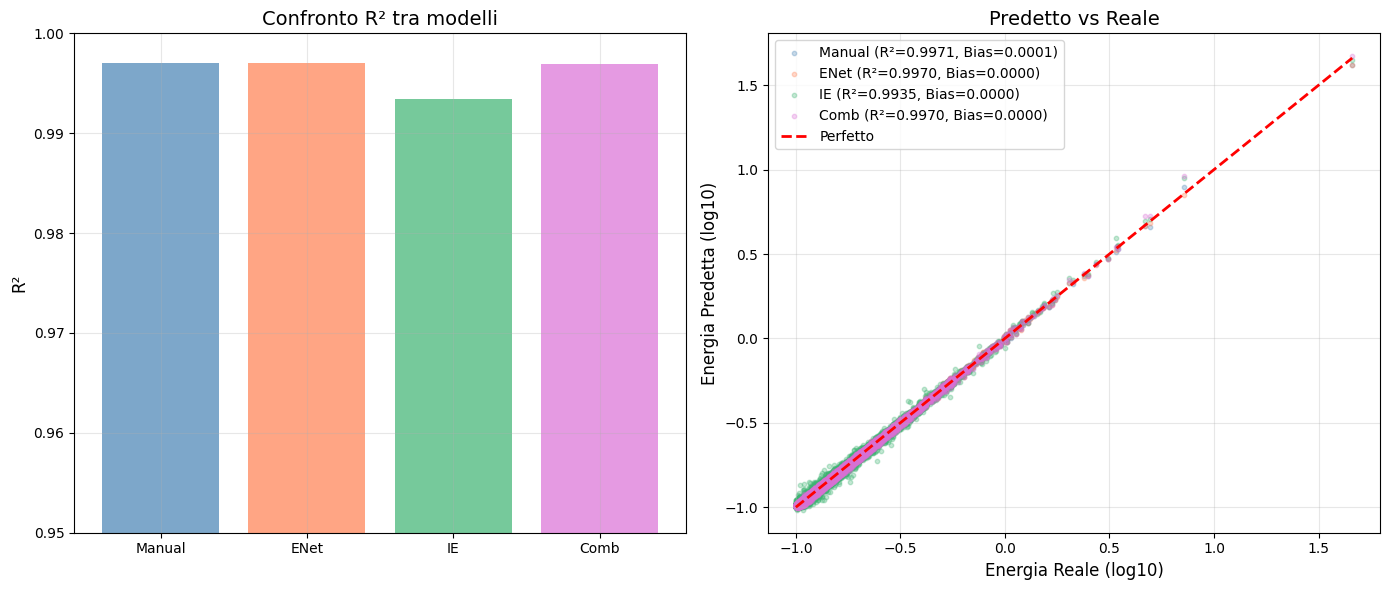


RIEPILOGO CONFRONTO
Modello                   R²         MSE          Variabili 
------------------------------------------------------------
Manual                    0.9971    0.000109          5
ENet                      0.9970    0.000111          3
IE                        0.9935    0.000242          4
Comb                      0.9970    0.000112          7

ANALISI COMPARATIVA

  Miglior modello: Selezione manuale (5 var)
   Residuals = 0.0104
   R² = 0.9971


In [10]:
from sklearn.ensemble import GradientBoostingRegressor

# Uso le stesse configurazioni del Random Forest per il Gradient Boosting Regressor

print("="*80, '\n')
print("             Gradient Boosting - Confronto Set di Variabili\n")
print("="*80, '\n')

# Miglioria computazionale, ma tempi di calcolo lunghi, quindi uso parametri fissi per il Gradient Boosting
param_grid_gb = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 0.9]
}

# --- Dizionario per salvare i risultati ---
results_gb = {}
models_gb = {}
predictions_gb = {}

# --- Ciclo su ogni configurazione ---
for config_name, config in configs.items():
    # 1. Seleziona le colonne per questo set
    colonne = config['colonne']
    nomi_var = config['nomi']
    conf_sigla = config['sigla']
    
    # 2. Prepara i dati
    if config_name == 'Variabili ingegnerizzate Elastic Net (4 var)':
        X_train = ing_vars[:train_size, colonne]
        X_test = ing_vars[train_size:, colonne]
    elif config_name == 'Combinazione (7 var)':
        X_train = comb_vars[:train_size, colonne]
        X_test = comb_vars[train_size:, colonne]
    else:
        X_train = set_of_vars[:train_size, colonne]
        X_test = set_of_vars[train_size:, colonne]
    y_train = energy[:train_size]
    y_test = energy[train_size:]
    
    print(f"\n{'='*50}")
    print(f"    {config_name}")
    print(f"{'='*50}\n")
    print(f"   Training set: {X_train.shape[0]} samples")
    print(f"   Test set: {X_test.shape[0]} samples")
    print(f"   Variabili: {X_train.shape[1]}\n")


    # 3. Addestra Gradient Boosting (base)
    if basic == False:
        gb = GradientBoostingRegressor(random_state=42)
        
        grid_search = GridSearchCV(
            estimator=gb,
            param_grid=param_grid_gb,
            cv=3,
            scoring='r2',
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)

        best_gb = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_cv_score = grid_search.best_score_

        importance = best_gb.feature_importances_

        y_pred = best_gb.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        residuals = y_test - y_pred
        bias = np.mean(y_test - y_pred)    

        print(f"\n     Migliori parametri:")
        for param, value in best_params.items():
            print(f"      {param}: {value}")
        print(f"\n   Performance:")
        print(f"     R² (CV): {best_cv_score:.4f}")
        print(f"     R² (test): {r2:.4f}")
        print(f"     MSE: {mse:.6f}")
        print(f"     Bias: {bias:.4f}")

    elif basic == True:
        gb = GradientBoostingRegressor(
            n_estimators=1000,
            learning_rate=0.1,
            max_depth=8,
            subsample=0.8,
            random_state=42
        )
        gb.fit(X_train, y_train)

        grid_search = gb  # Per uniformità di codice, anche se non c'è ricerca di griglia
        importance = gb.feature_importances_

        y_pred = gb.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        residuals = y_test - y_pred
        bias = np.mean(y_test - y_pred)

        print(f"\n   Performance:")
        print(f"     R² (test): {r2:.4f}")
        print(f"     MSE: {mse:.6f}")
        print(f"     Bias: {bias:.6f}")

    # 5. Importanza delle variabili
    print(f"\n     Importanza variabili:")
    # Ordina per importanza decrescente
    sorted_idx = np.argsort(importance)[::-1]
    for i in sorted_idx:
        if i < len(nomi_var):
            print(f"    {nomi_var[i]:<20}  {importance[i]:.4f}")
    print()

    # 6. Salva tutto
    results_gb[config_name] = {
        'r2': r2,
        'mse': mse,
        'bias': bias,
        'residuals': residuals,
        'n_var': X_train.shape[1]
    }
    if basic == False:
        models_gb[config_name] = best_gb
    elif basic == True:
        models_gb[config_name] = gb
    predictions_gb[config_name] = y_pred

# --- Grafico di confronto ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: R² e MSE a confronto
for i, (name, res) in enumerate(results_gb.items()):
    axes[0].bar(i, res['r2'], label=f"{configs[name]['sigla']}\n(R²={res['r2']:.4f})", 
                color=configs[name]['colore'], alpha=0.7)
axes[0].set_ylabel('R²', fontsize=12)
axes[0].set_title('Confronto R² tra modelli', fontsize=14)
axes[0].set_xticks(range(len(results_gb)))
axes[0].set_xticklabels([configs[name]['sigla'] for name in results_gb.keys()])
axes[0].grid(alpha=0.3)
for q in sorted(range(0, 20), reverse=True):
    if any(res['r2'] > q / 20 for res in results_gb.values()):
        axes[0].set_ylim(q / 20, 1)
        break
    else:
        axes[0].set_ylim(0, 1)

# Grafico 2: Predetto vs Reale per entrambi i modelli
for name, y_pred in predictions_gb.items():
    axes[1].scatter(energy[train_size:], y_pred, 
                    alpha=0.3, s=10, 
                    label=f"{configs[name]['sigla']} (R²={results_gb[name]['r2']:.4f}, Bias={results_gb[name]['bias']:.4f})",
                    color=configs[name]['colore'])
axes[1].plot([energy[train_size:].min(), energy[train_size:].max()], 
             [energy[train_size:].min(), energy[train_size:].max()], 
             'r--', lw=2, label='Perfetto')
axes[1].set_xlabel('Energia Reale (log10)', fontsize=12)
axes[1].set_ylabel('Energia Predetta (log10)', fontsize=12)
axes[1].set_title('Predetto vs Reale', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Riepilogo finale ---
print("\n" + "="*80)
print("RIEPILOGO CONFRONTO")
print("="*80)
print(f"{'Modello':<25} {'R²':<10} {'MSE':<12} {'Variabili':<10}")
print("-"*60)
for name, res in results_gb.items():
    name_clean = configs[name]['sigla']
    print(f"{name_clean:<25} {res['r2']:.4f}    {res['mse']:.6f}          {res['n_var']}")

# --- Analisi comparativa ---
print("\n" + "="*80)
print("ANALISI COMPARATIVA")
print("="*80)

# Trova il modello migliore da R^2 e dai residui 
best_model = max(results_gb, key=lambda x: results_gb[x]['r2'])  # Modello con il R² più alto
if len([x for x in results_rf if results_rf[x]['r2'] == results_rf[best_model]['r2']]) > 1:
    best_model = min(results_rf, key=lambda x: results_rf[x]['residuals'].std())  # Modello con la deviazione standard dei residui più bassa

best_r2 = results_gb[best_model]['r2']
print(f"\n  Miglior modello: {best_model}")
print(f"   Residuals = {results_gb[best_model]['residuals'].std():.4f}")
print(f"   R² = {best_r2:.4f}")



__Osservazioni (6)__

I risultati del Gradient Boosting mostrano un miglioramento rispetto al Random Forest, con una riduzione dell'errore quadratico medio (MSE) e un aumento del coefficiente di determinazione (R2). Tuttavia, è importante notare che il modello può essere sensibile ai parametri scelti, come il numero di alberi e la profondità massima degli stessi.

Il risultato più significativo sta nel riconoscere `sd_s450` come la variabile più importante per la predizione dell'energia dello sciame. Seguono `sd_gamma`, `sd_beta` e il quadrato del coseno dell'angolo zenitale, confermando l'importanza di queste misure nella ricostruzione dell'energia. Altre variabili come `sd_phi` e `sd_l` mostrano un contributo minore, suggerendo che la combinazione di misure dirette e variabili ingegnerizzate può portare a modelli più accurati.

## Modello XGBoost

Dopo aver analizzato i risultati ottenuti con il Gradient Boosting, si è deciso di implementare una versione migliorata del modello nota come *XGBoost*. Questo modello introduce diverse ottimizzazioni rispetto al Gradient Boosting tradizionale, tra cui una gestione più efficiente della memoria e una maggiore velocità di addestramento. Inoltre, XGBoost include tecniche di regolarizzazione che aiutano a prevenire l'overfitting, rendendolo particolarmente adatto per dataset complessi come quello dei raggi cosmici.


             XGBoost - Confronto Set di Variabili



    Selezione manuale (5 var)

   Training set: 43555 samples
   Test set: 10889 samples
   Variabili: 5


   Performance:
     R² (test): 0.9924
     MSE: 0.000281
     Bias: -0.000061

     Importanza variabili:
    sd_s450               0.5919
    sd_l                  0.3412
    sd_beta               0.0362
    sd_gamma              0.0261
    cos(theta)            0.0046


    Elastic Net (3 var)

   Training set: 43555 samples
   Test set: 10889 samples
   Variabili: 3


   Performance:
     R² (test): 0.9933
     MSE: 0.000248
     Bias: 0.000025

     Importanza variabili:
    sd_s450               0.5391
    sd_gamma              0.4213
    cos(theta)            0.0396


    Variabili ingegnerizzate Elastic Net (4 var)

   Training set: 43555 samples
   Test set: 10889 samples
   Variabili: 4


   Performance:
     R² (test): 0.9897
     MSE: 0.000381
     Bias: -0.000012

     Importanza variabili:
    sd_s450^2           

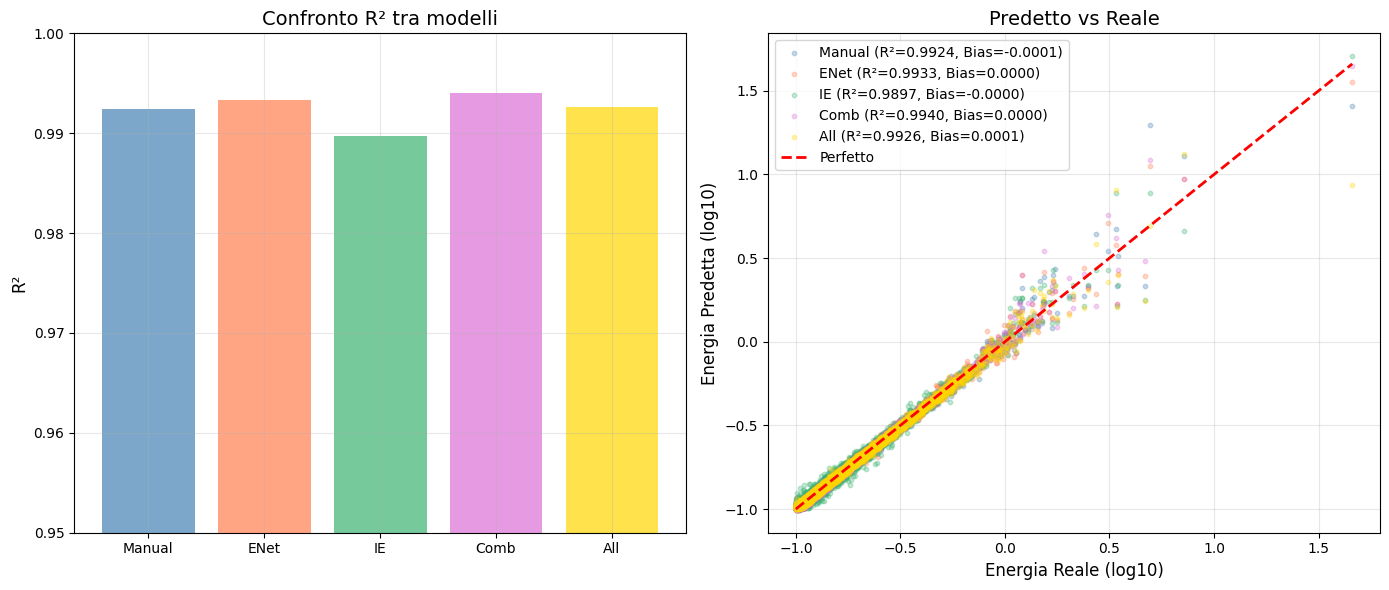


RIEPILOGO CONFRONTO
Modello                   R²         MSE          Variabili 
------------------------------------------------------------
Manual                    0.9924    0.000281          5
ENet                      0.9933    0.000248          3
IE                        0.9897    0.000381          4
Comb                      0.9940    0.000222          7
All                       0.9926    0.000274          18

ANALISI COMPARATIVA

  Miglior modello: Combinazione (7 var)
   Residuals = 0.0149
   R² = 0.9940


In [11]:
import xgboost as xgb

# Uso le stesse configurazioni del Random Forest per il Gradient Boosting Regressor
configs = {
    'Selezione manuale (5 var)': {
        'colonne': keep_idx,  # Le 5 variabili selezionate manualmente
        'nomi': keep_list,
        'colore': 'steelblue',
        'sigla': 'Manual'
    },
    'Elastic Net (3 var)': {
        'colonne': selected_enet,  # Le variabili selezionate dal primo Elastic Net
        'nomi': [this_varlist[i] for i in selected_enet],
        'colore': 'coral',
        'sigla': 'ENet'
    },
    'Variabili ingegnerizzate Elastic Net (4 var)': {
        'colonne': selected_ie,  # Le variabili ingegnerizzate selezionate dal secondo Elastic Net
        'nomi': [ing_list[i] for i in selected_ie],
        'colore': 'mediumseagreen',
        'sigla': 'IE'
    },
    'Combinazione (7 var)': {
        'colonne': selected_comb,  # Le variabili combinate selezionate dal terzo Elastic Net
        'nomi': [comb_list[i] for i in selected_comb],
        'colore': 'orchid',
        'sigla': 'Comb'
    },
    'Tutte le variabili (18 var)': {
        'colonne': list(range(set_of_vars.shape[1])),  # Tutte le variabili disponibili
        'nomi': this_varlist,
        'colore': 'gold',
        'sigla': 'All'
    }
}


print("="*80, '\n')
print("             XGBoost - Confronto Set di Variabili\n")
print("="*80, '\n')

# Più parametri perché più veloce e più efficiente di Gradient Boosting Regressor
param_grid_xgb = {
    'n_estimators': [1000, 1500, 2000],
    'learning_rate': [0.01, 0.03, 0.05],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# --- Dizionario per salvare i risultati ---
results_xgb = {}
models_xgb = {}
predictions_xgb = {}

# --- Ciclo su ogni configurazione ---
for config_name, config in configs.items():
    # 1. Seleziona le colonne per questo set
    colonne = config['colonne']
    nomi_var = config['nomi']
    conf_sigla = config['sigla']
    
    # 2. Prepara i dati
    if config_name == 'Variabili ingegnerizzate Elastic Net (4 var)':
        X_train = ing_vars[:train_size, colonne]
        X_test = ing_vars[train_size:, colonne]
    elif config_name == 'Combinazione (7 var)':
        X_train = comb_vars[:train_size, colonne]
        X_test = comb_vars[train_size:, colonne]
    else:
        X_train = set_of_vars[:train_size, colonne]
        X_test = set_of_vars[train_size:, colonne]
    y_train = energy[:train_size]
    y_test = energy[train_size:]
    
    print(f"\n{'='*50}")
    print(f"    {config_name}")
    print(f"{'='*50}\n")
    print(f"   Training set: {X_train.shape[0]} samples")
    print(f"   Test set: {X_test.shape[0]} samples")
    print(f"   Variabili: {X_train.shape[1]}\n")

    # 3. Addestra Gradient Boosting (base)
    if basic == False:
        model_xgb = xgb.XGBRegressor(random_state=42, n_jobs=-1)

        grid_search = GridSearchCV(
            estimator=model_xgb,
            param_grid=param_grid_xgb,
            cv=3,
            scoring='r2',
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train)

        best_xgb = grid_search.best_estimator_
        best_params = grid_search.best_params_
        best_cv_score = grid_search.best_score_

        importance = best_xgb.feature_importances_

        y_pred = best_xgb.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        residuals = y_test - y_pred
        bias = np.mean(y_test - y_pred)

        print(f"\n     Migliori parametri:")
        for param, value in best_params.items():
            print(f"      {param}: {value}")
        print(f"\n   Performance:")
        print(f"     R² (CV): {best_cv_score:.4f}")
        print(f"     R² (test): {r2:.4f}")
        print(f"     MSE: {mse:.6f}")
        print(f"     Bias: {bias:.4f}")

    elif basic == True:
        model_xgb = xgb.XGBRegressor(
            n_estimators=2000,
            learning_rate=0.05,
            max_depth=15,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
        model_xgb.fit(X_train, y_train)

        grid_search = model_xgb  # Per uniformità di codice, anche se non c'è ricerca di griglia
        importance = model_xgb.feature_importances_

        y_pred = model_xgb.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        residuals = y_test - y_pred
        bias = np.mean(y_test - y_pred)

        print(f"\n   Performance:")
        print(f"     R² (test): {r2:.4f}")
        print(f"     MSE: {mse:.6f}")
        print(f"     Bias: {bias:.6f}")
    

    # 5. Importanza delle variabili
    
    print(f"\n     Importanza variabili:")
    # Ordina per importanza decrescente
    sorted_idx = np.argsort(importance)[::-1]
    for i in sorted_idx:
        if i < len(nomi_var):
            print(f"    {nomi_var[i]:<20}  {importance[i]:.4f}")
    print()

    # 6. Salva tutto
    results_xgb[config_name] = {
        'r2': r2,
        'mse': mse,
        'bias': bias,
        'residuals': residuals,
        'n_var': X_train.shape[1]
    }
    if basic == False:
        models_xgb[config_name] = best_xgb
    elif basic == True:
        models_xgb[config_name] = model_xgb
    predictions_xgb[config_name] = y_pred

# --- Grafico di confronto ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Grafico 1: R² e MSE a confronto
for i, (name, res) in enumerate(results_xgb.items()):
    axes[0].bar(i, res['r2'], label=f"{configs[name]['sigla']}\n(R²={res['r2']:.4f})", 
                color=configs[name]['colore'], alpha=0.7)
axes[0].set_ylabel('R²', fontsize=12)
axes[0].set_title('Confronto R² tra modelli', fontsize=14)
axes[0].set_xticks(range(len(results_xgb)))
axes[0].set_xticklabels([configs[name]['sigla'] for name in results_xgb.keys()])
axes[0].grid(alpha=0.3)
for q in sorted(range(0, 20), reverse=True):
    if any(res['r2'] > q / 20 for res in results_xgb.values()):
        axes[0].set_ylim(q / 20, 1)
        break
    else:
        axes[0].set_ylim(0, 1)

# Grafico 2: Predetto vs Reale per entrambi i modelli
for name, y_pred in predictions_xgb.items():
    axes[1].scatter(energy[train_size:], y_pred, 
                    alpha=0.3, s=10, 
                    label=f"{configs[name]['sigla']} (R²={results_xgb[name]['r2']:.4f}, Bias={results_xgb[name]['bias']:.4f})",
                    color=configs[name]['colore'])
axes[1].plot([energy[train_size:].min(), energy[train_size:].max()], 
             [energy[train_size:].min(), energy[train_size:].max()], 
             'r--', lw=2, label='Perfetto')
axes[1].set_xlabel('Energia Reale (log10)', fontsize=12)
axes[1].set_ylabel('Energia Predetta (log10)', fontsize=12)
axes[1].set_title('Predetto vs Reale', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Riepilogo finale ---
print("\n" + "="*80)
print("RIEPILOGO CONFRONTO")
print("="*80)
print(f"{'Modello':<25} {'R²':<10} {'MSE':<12} {'Variabili':<10}")
print("-"*60)
for name, res in results_xgb.items():
    name_clean = configs[name]['sigla']
    print(f"{name_clean:<25} {res['r2']:.4f}    {res['mse']:.6f}          {res['n_var']}")

# --- Analisi comparativa ---
print("\n" + "="*80)
print("ANALISI COMPARATIVA")
print("="*80)

# Trova il modello migliore dai residui 
best_model = min(results_xgb, key=lambda x: results_xgb[x]['residuals'].std())  # Modello con la deviazione standard dei residui più bassa
best_r2 = results_xgb[best_model]['r2']
print(f"\n  Miglior modello: {best_model}")
print(f"   Residuals = {results_xgb[best_model]['residuals'].std():.4f}")
print(f"   R² = {best_r2:.4f}")



__OSSERVAZIONI (6)__

I risultati di XGBoost, anche se con R^2 leggermente inferiori rispetto al Gradient Boosting, mostrano dei risultati analoghi agli altri metodi non lineari, confermando la validità dell'approccio ML per la ricostruzione dell'energia degli sciami cosmici. In particolare, l'uso di variabili ingegnerizzate e la combinazione con l'Elastic Net continuano a fornire miglioramenti nelle performance del modello.

Si può notare come la variabile più importante per la predizione dell'energia dello sciame sia `sd_s450`, confermando l'importanza di questa misura nella ricostruzione dell'energia. Altre variabili come `sd_gamma` e il quadrato del coseno dell'angolo zenitale continuano a mostrare un contributo significativo, suggerendo che la combinazione di misure dirette e variabili ingegnerizzate può portare a modelli più accurati.


## Conclusioni

Facciamo un quadro generale e riassumiamo i risultati ottenuti dai modelli di regressione lineare e non lineare applicati al dataset di Auger.

ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (7,) and arg 1 with shape (10,).

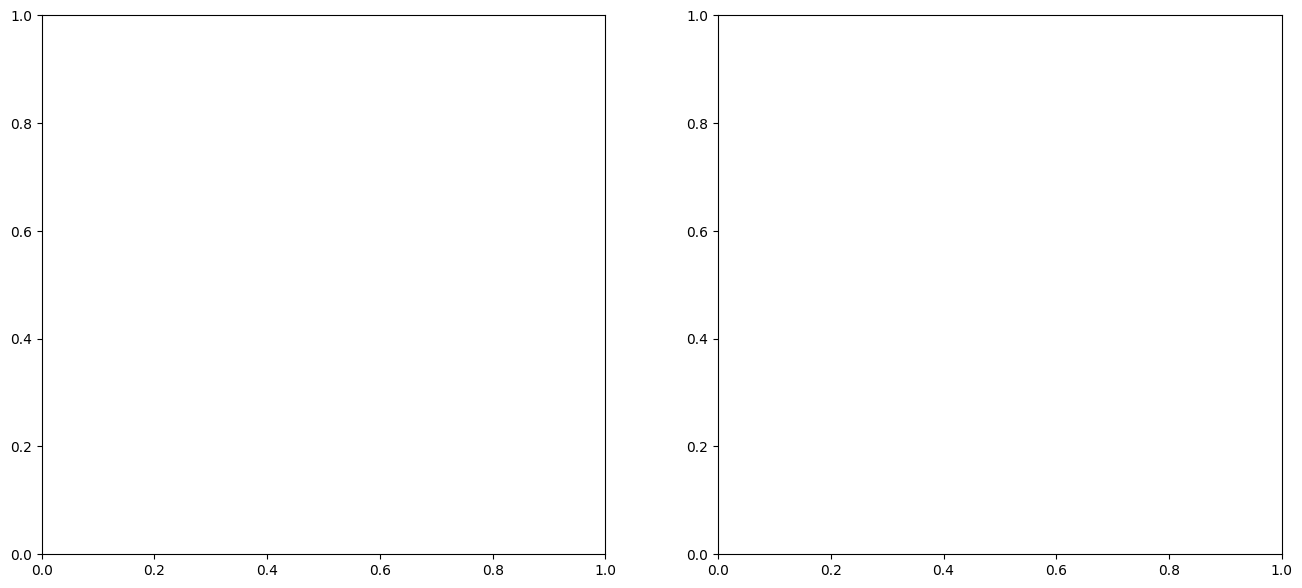

In [ ]:
# Serie di grafici riassutivi
# Racchiudiamo in un grafico riassuntivo gli andamenti lineari rispetto ai dati effettivi.
# Poi confrontiamo tutti gli r^2, MSE e bias dei modelli, per capire quale sia il migliore.
# Evenmtualmente si può fare un grafico di importanza delle variabili.

# --- Dati ---
modelli = [
    'Lineare\n(manuale)',
    'EN\n(3 var)',
    'EN\n(ingeg)',
    'EN\n(comb)',
    'RF',
    'GB',
    'XGB'
]

all_r2 = []
all_r2.append(r2)
all_r2.append(enet_r2)
all_r2.append(ie_r2)
all_r2.append(comb_r2)

all_mse = []
all_mse.append(mse)
all_mse.append(enet_mse)
all_mse.append(ie_mse)
all_mse.append(comb_mse)

# Dei modelli non lineari, prendo il migliore in termini di R² e lo aggiungo alla lista sia di R² che di MSE
for _appx in ['_rf', '_gb', '_xgb']:
    results_key = f'results{_appx}'
    results = globals()[results_key]
    best_model = max(results, key=lambda x: results[x]['r2'])  # Modello con il R² più alto
    # occhio a R^2 uguali
    if len([x for x in results if results[x]['r2'] == results[best_model]['r2']]) > 1:
        best_model = min(results, key=lambda x: results[x]['residuals'].std())  # Modello con la deviazione standard dei residui più bassa
    best_r2 = results[best_model]['r2']
    best_mse = results[best_model]['mse']
    all_r2.append(best_r2)
    all_mse.append(best_mse)

print('Lunghezze liste:', len(x), len(all_r2), len(all_mse))

# Colori per i modelli
colors = ["#ee1313", '#ff7f0e', "#f3ef07", "#4fef0a", "#0df7ff", "#0040ff", "#bc12da"]

# --- Creazione dei subplot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

x = np.arange(len(modelli))
width = 0.6

# ============================================
# SUBPLOT 1: R²
# ============================================
bars_r2 = ax1.bar(x, all_r2, width, color=colors, edgecolor='black', linewidth=1, alpha=0.85)
ax1.set_ylabel('R²', fontsize=14)
ax1.set_ylim(0, 1.05)
ax1.set_xticks(x)
ax1.set_xticklabels(modelli, fontsize=11)
ax1.set_title('Confronto R²', fontsize=16)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# --- Evidenzia GB con riquadro nero spesso ---
bars_r2[5].set_edgecolor('black')
bars_r2[5].set_linewidth(3.5)

# Annotazioni R²
for i, (bar, val) in enumerate(zip(bars_r2, all_r2)):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10)

# ============================================
# SUBPLOT 2: MSE (scala logaritmica)
# ============================================
bars_mse = ax2.bar(x, all_mse, width, color=colors, edgecolor='black', linewidth=1, alpha=0.85)
ax2.set_ylabel('MSE (log scale)', fontsize=14)
ax2.set_yscale('log')
ax2.set_xticks(x)
ax2.set_xticklabels(modelli, fontsize=11)
ax2.set_title('Confronto MSE', fontsize=16)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# --- Evidenzia GB con riquadro nero spesso ---
bars_mse[5].set_edgecolor('black')
bars_mse[5].set_linewidth(3.5)

# Annotazioni MSE
for i, (bar, val) in enumerate(zip(bars_mse, all_mse)):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.05,
             f'{val:.6f}', ha='center', va='bottom', fontsize=9)

# ============================================
# Linea di separazione tra modelli lineari e non
# ============================================
for ax in [ax1, ax2]:
    ax.axvline(x=3.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)

# ============================================
# Layout e salvataggio
# ============================================
plt.subplots_adjust(wspace=0.3)  # Aumenta lo spazio orizzontale tra i subplot
plt.tight_layout()
plt.show()